# Laboratorio 01 - Regresión Lineal
## Dataset: Poker Hand (UCI Machine Learning Repository)

### ¿Cómo funciona el dataset?

El dataset **Poker Hand** representa manos de póker. Cada fila es una mano de 5 cartas,
descrita por 10 columnas: el **palo** (S) y el **rango** (C) de cada carta.

- **S** (Suit/Palo): 1=Corazones, 2=Picas, 3=Diamantes, 4=Tréboles
- **C** (Card/Rango): 1=As, 2 al 10=Número, 11=J, 12=Q, 13=K
- **CLASS** (objetivo): el tipo de mano que forman las 5 cartas, del 0 al 9
  (0=Nada, 1=Par, 2=Doble Par, 3=Trío, 4=Escalera, 5=Color,
  6=Full House, 7=Póker, 8=Escalera de Color, 9=Escalera Real)

### ¿Qué estamos aplicando y cómo?

Aplicamos **Regresión Lineal Múltiple** usando las 10 columnas (S1,C1,...,S5,C5)
como variables de entrada `X`, y la clase de la mano como variable objetivo `y`.
El modelo aprende los pesos `theta` mediante **descenso por el gradiente**,
minimizando la función de costo `J(theta)` para que dado un conjunto de cartas,
pueda predecir a qué clase pertenece esa mano.


In [61]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Libreria para manejo de datos
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 1. Regresión lineal con múltiples variables

El archivo `poker-hand-training-true.data` contiene el dataset Poker Hand.
Tiene 10 características (palo y rango de cada carta) y una variable objetivo (clase de la mano).

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
# Nombres de columnas
nombres_col = ['S1','C1','S2','C2','S3','C3','S4','C4','S5','C5']
columnas    = nombres_col + ['CLASS']

# Leer datos con Pandas
df = pd.read_csv('/content/drive/MyDrive/IA/LAB01/poker-hand-training-true.data', header=None, names=columnas)

# Separar características y objetivo
X = df[nombres_col].values
y = df['CLASS'].values

m = y.size  # m = numero de ejemplos de entrenamiento

print(df.head(10))

   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5  CLASS
0   1  10   1  11   1  13   1  12   1   1      9
1   2  11   2  13   2  10   2  12   2   1      9
2   3  12   3  11   3  13   3  10   3   1      9
3   4  10   4  11   4   1   4  13   4  12      9
4   4   1   4  13   4  12   4  11   4  10      9
5   1   2   1   4   1   5   1   3   1   6      8
6   1   9   1  12   1  10   1  11   1  13      8
7   2   1   2   2   2   3   2   4   2   5      8
8   3   5   3   6   3   9   3   7   3   8      8
9   4   1   4   4   4   2   4   3   4   5      8


In [64]:
print(X)

[[ 1 10  1 ... 12  1  1]
 [ 2 11  2 ... 12  2  1]
 [ 3 12  3 ... 10  3  1]
 ...
 [ 2  1  2 ...  1  4 13]
 [ 2 12  4 ... 12  4  9]
 [ 1  7  3 ...  8  3  7]]


In [65]:
print(y)

[9 9 9 ... 1 1 1]


### Trazado de los datos

Se grafica la primera característica (C1 = rango de la primera carta) contra la clase,
para visualizar la distribución general de los datos.

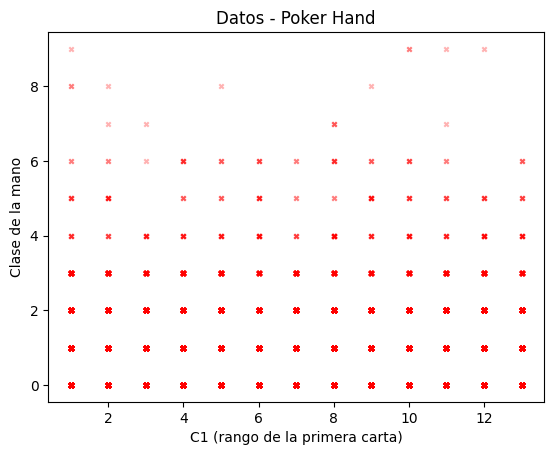

In [66]:
pyplot.scatter(X[:, 1], y, marker='x', c='red', s=10, alpha=0.3)
pyplot.ylabel('Clase de la mano')
pyplot.xlabel('C1 (rango de la primera carta)')
pyplot.title('Datos - Poker Hand')
pyplot.show()

### Normalización de características

Al tener múltiples características con escalas distintas, se normalizan antes del descenso por el gradiente.

In [67]:
def normalizarCaracteristicas(X):
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X,  axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizarCaracteristicas(X)

# Agregar columna de unos (termino de sesgo theta_0)
X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f'Dimensiones de X con columna de unos: {X_norm.shape}')

Dimensiones de X con columna de unos: (25010, 11)


### Función de costo

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

In [68]:
def calcularCosto(X, y, theta):
    m = len(y)
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum((h - y) ** 2)
    return J

# Prueba con theta = ceros
theta = np.zeros(X_norm.shape[1])
J = calcularCosto(X_norm, y, theta)
print(f'Costo con theta = ceros: {J:.4f}')

Costo con theta = ceros: 0.5037


### Descenso por el gradiente

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

In [69]:
def gradienteDescendente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = []

    for i in range(num_iters):
        h     = np.dot(X, theta)
        error = h - y
        theta = theta - (alpha / m) * np.dot(X.T, error)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

# Parametros de entrenamiento
alpha     = 0.01
num_iters = 1500

theta = np.zeros(X_norm.shape[1])
theta, J_history = gradienteDescendente(X_norm, y, theta, alpha, num_iters)

print('Theta calculado por el descenso por el gradiente:')
print(theta)

Theta calculado por el descenso por el gradiente:
[ 0.62115136  0.00640714  0.00182616 -0.00086844 -0.00416696  0.00311889
 -0.00486389 -0.00114631  0.00785893 -0.00422569 -0.00191661]


### Graficar la línea ajustada sobre los datos

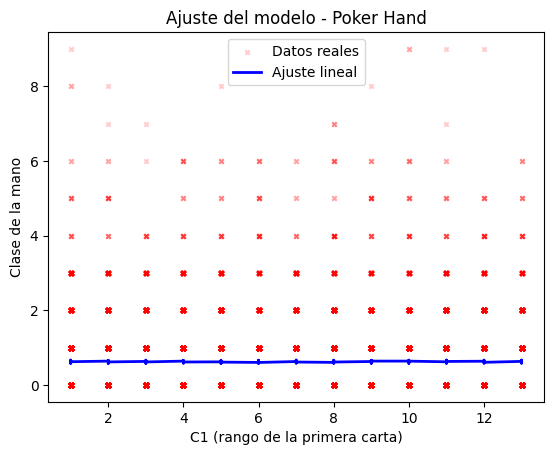

In [70]:
# Predicciones del modelo sobre todos los datos
y_pred = np.dot(X_norm, theta)

# Ordenar por C1 para trazar la línea
idx_orden = np.argsort(X[:, 1])

pyplot.scatter(X[:, 1], y, marker='x', c='red', s=10, alpha=0.2, label='Datos reales')
pyplot.plot(X[idx_orden, 1], y_pred[idx_orden], '-', color='blue', lw=2, label='Ajuste lineal')
pyplot.ylabel('Clase de la mano')
pyplot.xlabel('C1 (rango de la primera carta)')
pyplot.title('Ajuste del modelo - Poker Hand')
pyplot.legend()
pyplot.show()

### Predicciones (Inferencias)

In [71]:
clases_nombres = {
    0:'Nada', 1:'Par', 2:'Doble Par', 3:'Trío',
    4:'Escalera', 5:'Color', 6:'Full House',
    7:'Póker', 8:'Escal. Color', 9:'Escal. Real'
}

# Mano 1: posible Escalera Real [S=1,C=10 | S=1,C=11 | S=1,C=12 | S=1,C=13 | S=1,C=1]
mano1 = np.array([1,10, 1,11, 1,12, 1,13, 1,1])
mano1_norm = (mano1 - mu) / sigma
pred1 = np.dot(np.concatenate([[1], mano1_norm]), theta)
pred1_r = int(round(np.clip(pred1, 0, 9)))
print(f'Mano 1: {mano1}')
print(f'Clase predicha: {pred1:.4f} -> {pred1_r} ({clases_nombres[pred1_r]})')
print()

# Mano 2: mano sin combinacion
mano2 = np.array([1,2, 2,5, 3,8, 4,11, 1,4])
mano2_norm = (mano2 - mu) / sigma
pred2 = np.dot(np.concatenate([[1], mano2_norm]), theta)
pred2_r = int(round(np.clip(pred2, 0, 9)))
print(f'Mano 2: {mano2}')
print(f'Clase predicha: {pred2:.4f} -> {pred2_r} ({clases_nombres[pred2_r]})')

Mano 1: [ 1 10  1 11  1 12  1 13  1  1]
Clase predicha: 0.6230 -> 1 (Par)

Mano 2: [ 1  2  2  5  3  8  4 11  1  4]
Clase predicha: 0.6269 -> 1 (Par)


### Superficie, Contorno y Convergencia del costo

Se visualiza el costo J en función de theta_0 y theta_1 (los dos primeros parámetros),
y la convergencia del costo durante el entrenamiento.

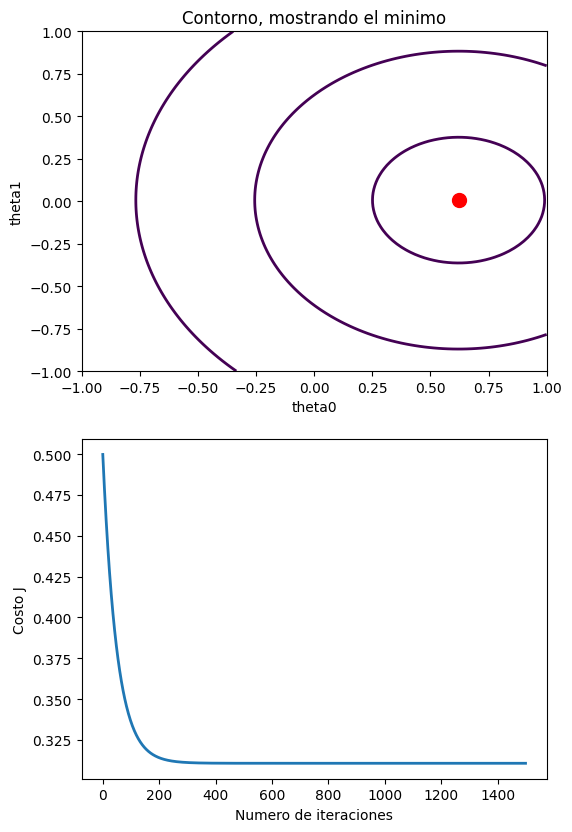

In [73]:
# Cuadricula sobre la que se calcula J (usando solo theta_0 y theta_1)
theta0_vals = np.linspace(-1, 1, 100)
theta1_vals = np.linspace(-1, 1, 100)

# Inicializa J_vals con una matriz de 0's
J_vals = np.zeros((theta0_vals.shape[0], theta1_vals.shape[0]))

# Usar solo las dos primeras columnas de X_norm para la visualizacion
X_vis = X_norm[:, :2]

# Completar J_vals
for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        J_vals[i, j] = calcularCosto(X_vis, y, [t0, t1])

# Transponer J_vals antes de graficar
J_vals = J_vals.T

# Graficar superficie, contorno y convergencia
fig = pyplot.figure(figsize=(6, 15))

# Contorno
ax = pyplot.subplot(312)
pyplot.contour(theta0_vals, theta1_vals, J_vals, linewidths=2, cmap='viridis',
               levels=np.logspace(-2, 3, 20))
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.plot(theta[0], theta[1], 'ro', ms=10, lw=2)
pyplot.title('Contorno, mostrando el minimo')

# Convergencia del costo
ax = pyplot.subplot(313)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

pass